In [1]:
import os
os.getcwd()

'C:\\Users\\ayesh\\OneDrive\\Desktop\\Blinkit-Sales_Analysis\\notebooks'

In [2]:
os.listdir("../data")

['archive (1)']

In [3]:
os.listdir("../data/archive (1)")

['blinkit_customers.csv',
 'blinkit_customer_feedback.csv',
 'blinkit_delivery_performance.csv',
 'blinkit_inventory.csv',
 'blinkit_inventoryNew.csv',
 'blinkit_marketing_performance.csv',
 'blinkit_orders.csv',
 'blinkit_order_items.csv',
 'blinkit_products.csv',
 'Category_Icons.xlsx',
 'Rating_Icon.xlsx']

# Blinkit Sales Analysis

## 1. Import Libraries

## 2. Load Datasets

## 3. Data Understanding

## 4. Data Cleaning

## 5. Exploratory Data Analysis

### Analysis 1: Total Revenue
### Analysis 2: Payment Method Distribution
### Analysis 3: Delivery Status
### Analysis 4: Revenue by Store
### Analysis 5: Orders Over Time
### Analysis 6: Product Analysis

In [4]:
import pandas as pd

orders = pd.read_csv("../data/archive (1)/blinkit_orders.csv")

In [5]:
orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [6]:
orders.shape

(5000, 10)

In [7]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='str')

In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   str    
 3   promised_delivery_time  5000 non-null   str    
 4   actual_delivery_time    5000 non-null   str    
 5   delivery_status         5000 non-null   str    
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   str    
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 739.9 KB


In [9]:
orders.isnull().sum()

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

In [10]:
orders.duplicated().sum()

np.int64(0)

In [11]:
orders.describe()

,order_id,customer_id,order_total,delivery_partner_id,store_id
count,5.000000e+03,5.000000e+03,5000.00000,5000.000000,5000.000000
mean,5.029129e+09,5.009685e+07,2201.86170,50050.318200,4999.689000
std,2.863533e+09,2.919082e+07,1303.02438,28802.276922,2886.089242
min,6.046500e+04,3.181300e+04,13.25000,43.000000,1.000000
25%,2.531421e+09,2.404314e+07,1086.21500,24928.500000,2509.250000
50%,5.074378e+09,4.997808e+07,2100.69000,50262.500000,4987.000000
75%,7.488579e+09,7.621215e+07,3156.88250,74478.250000,7500.750000
max,9.998298e+09,9.989390e+07,6721.46000,99968.000000,9995.000000


In [12]:
#to check the total revenue
orders["order_total"].sum()

np.float64(11009308.5)

In [13]:
import matplotlib.pyplot as plt

In [14]:
#Counting Orders by Payment Method
payment_counts = orders["payment_method"].value_counts()
payment_counts

payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64

## Analysis 1: Payment Method Analysis

### Business Question
Which payment method is preferred by customers?

### Observation
Card payments account for the highest number of orders (1,285), followed closely by Cash, Wallet, and UPI. The distribution is fairly balanced, indicating customers are comfortable using multiple payment options.

### Business Insight
Blinkit should continue supporting multiple payment methods while introducing promotional offers for digital payments like UPI and Wallet to encourage cashless transactions.

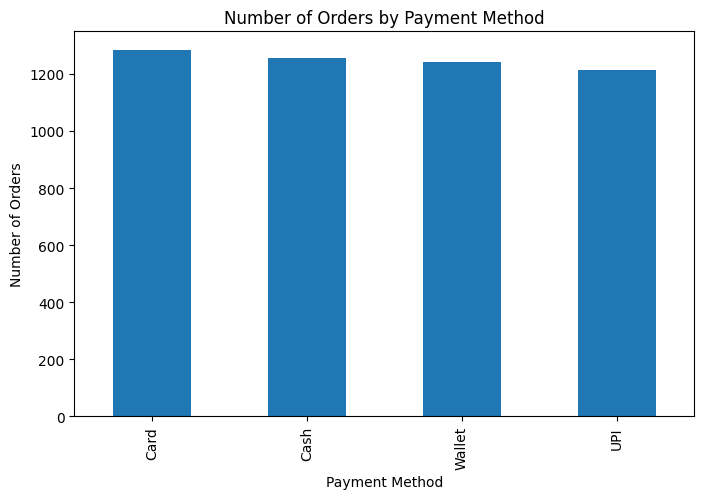

In [15]:
#Creating Bar Chart
plt.figure(figsize=(8,5))
payment_counts.plot(kind="bar")
plt.title("Number of Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

In [16]:
delivery_status = orders["delivery_status"].value_counts()
delivery_status

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

## Analysis 2: Delivery Status Analysis

### Business Question
What is the distribution of delivery statuses?

### Observation
The chart shows the number of orders for each delivery status.

### Business Insight
This analysis helps identify operational performance. A high number of delayed or cancelled orders may indicate delivery bottlenecks and areas where service quality can be improved.

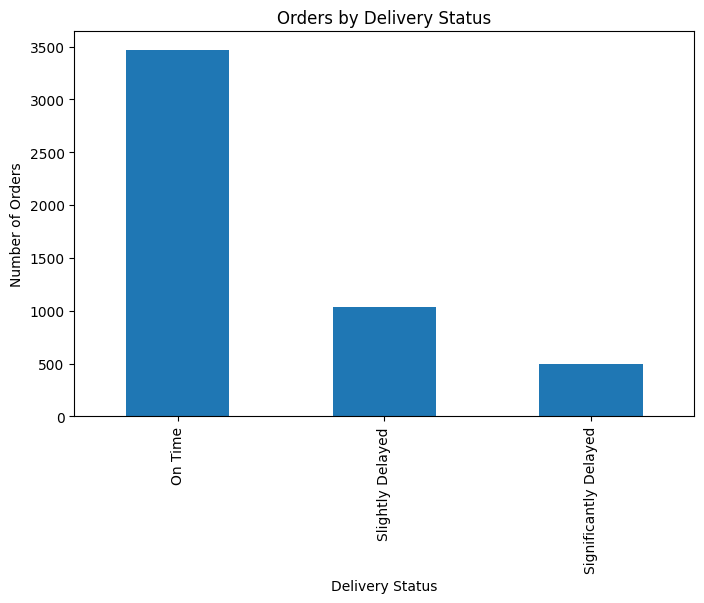

In [17]:
plt.figure(figsize=(8,5))
delivery_status.plot(kind="bar")
plt.title("Orders by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.show()

## Analysis 3: Revenue by Store

### Business Question
Which stores generate the highest revenue?

### Observation
The chart compares total revenue generated by each Blinkit store.

### Business Insight
High-performing stores can be used as benchmarks to improve the performance of lower-performing stores through better inventory management, staffing, and operational practices.

store_revenue = orders.groupby("store_id")["order_total"].sum().sort_values(ascending=False)
store_revenue

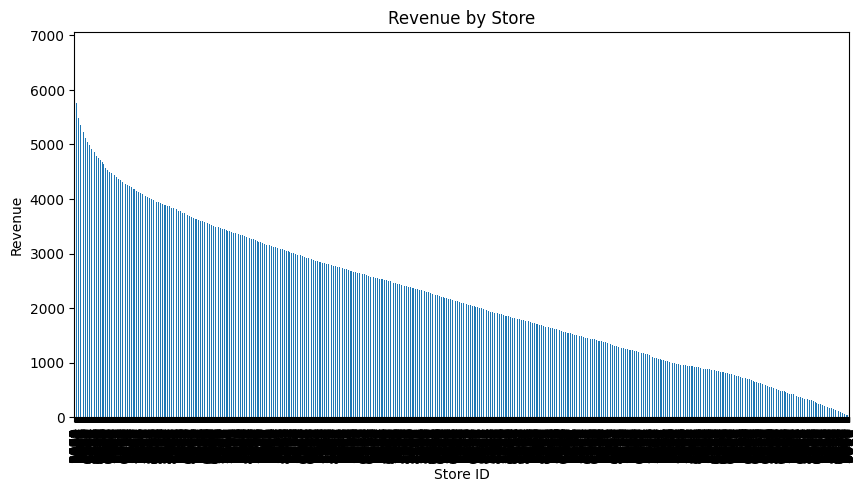

In [19]:
plt.figure(figsize=(10,5))
store_revenue.plot(kind="bar")
plt.title("Revenue by Store")
plt.xlabel("Store ID")
plt.ylabel("Revenue")
plt.show()

## Analysis 4: Orders Over Time

### Business Question
How has the number of orders changed over time?

### Observation
The line chart shows daily order volume over the available time period.

### Business Insight
Understanding order trends helps Blinkit forecast demand, optimize staffing, and manage inventory more effectively during peak periods.

In [21]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [22]:
orders_per_day = orders.groupby("order_date").size()
orders_per_day

order_date
2023-03-16 08:10:44    1
2023-03-16 08:31:08    1
2023-03-16 09:09:00    1
2023-03-16 11:38:32    1
2023-03-16 14:07:42    1
                      ..
2024-11-03 16:41:57    1
2024-11-04 00:15:51    1
2024-11-04 01:16:31    1
2024-11-04 13:50:21    1
2024-11-04 20:29:15    1
Length: 5000, dtype: int64

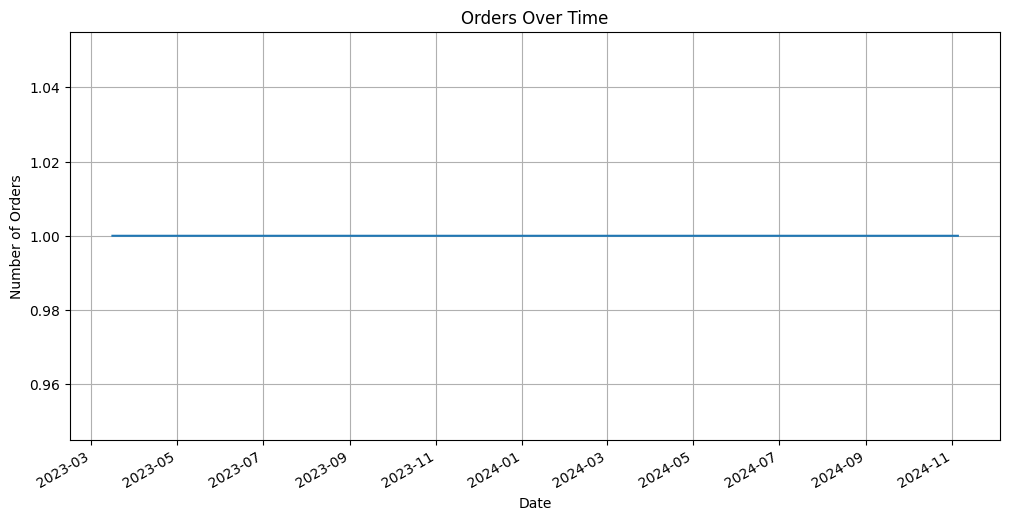

In [23]:
plt.figure(figsize=(12,6))

orders_per_day.plot(kind="line")

plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.show()

In [24]:
order_items = pd.read_csv("../data/archive (1)/blinkit_order_items.csv")


In [25]:
order_items.head()

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55


In [26]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    5000 non-null   int64  
 1   product_id  5000 non-null   int64  
 2   quantity    5000 non-null   int64  
 3   unit_price  5000 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 156.4 KB


In [27]:
order_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='str')

In [28]:
order_items.shape

(5000, 4)

In [29]:
order_items.isnull().sum()

order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64

In [30]:
products = pd.read_csv("../data/archive (1)/blinkit_products.csv")

In [31]:
products.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [32]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         268 non-null    int64  
 1   product_name       268 non-null    str    
 2   category           268 non-null    str    
 3   brand              268 non-null    str    
 4   price              268 non-null    float64
 5   mrp                268 non-null    float64
 6   margin_percentage  268 non-null    float64
 7   shelf_life_days    268 non-null    int64  
 8   min_stock_level    268 non-null    int64  
 9   max_stock_level    268 non-null    int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 31.2 KB


In [33]:
orders_items = pd.merge(
    orders,
    order_items,
    on="order_id",
    how="inner"
)

In [34]:
orders_items.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,product_id,quantity,unit_price
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,642612,3,517.03
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,378676,1,881.42
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,741341,2,923.84
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,561860,1,874.78
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,602241,2,976.55


In [35]:
orders_items.shape

(5000, 13)

In [36]:
products.columns

Index(['product_id', 'product_name', 'category', 'brand', 'price', 'mrp',
       'margin_percentage', 'shelf_life_days', 'min_stock_level',
       'max_stock_level'],
      dtype='str')

In [37]:
master_data = pd.merge(
    orders_items,
    products,
    on="product_id",
    how="inner"
)

In [38]:
master_data.shape

(5000, 22)

In [39]:
master_data.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,unit_price,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,365,16,57
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,180,19,65
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,7,13,62
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,180,21,90
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,90,12,75


In [40]:
master_data.groupby("product_name")["quantity"].sum()

product_name
Baby Food            236
Baby Wipes           328
Bananas               85
Biscuits             247
Bread                270
Butter               148
Carrots              191
Cat Food             307
Cereal                86
Cheese               182
Chips                171
Chocolates           131
Cola                 230
Cookies               97
Cough Syrup          373
Curd                 126
Detergent            251
Diapers               91
Dish Soap            397
Dog Food             223
Eggs                 246
Frozen Biryani       254
Frozen Pizza         180
Frozen Vegetables    137
Ice Cream             98
Iced Tea             118
Instant Noodles       73
Lemonade              45
Lotion               350
Mango Drink          143
Mangoes              101
Milk                  56
Nuts                 134
Onions               222
Orange Juice         222
Pain Reliever        220
Pet Treats           473
Popcorn              183
Potatoes             230
Pulses      

In [41]:
master_data = pd.merge(
    orders_items,
    products,
    on="product_id",
    how="inner"
)

master_data.shape
master_data.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,unit_price,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,365,16,57
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,180,19,65
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,7,13,62
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,180,21,90
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,90,12,75


In [42]:
master_data.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'product_id',
       'quantity', 'unit_price', 'product_name', 'category', 'brand', 'price',
       'mrp', 'margin_percentage', 'shelf_life_days', 'min_stock_level',
       'max_stock_level'],
      dtype='str')

In [44]:
master_data.columns.tolist()

['order_id',
 'customer_id',
 'order_date',
 'promised_delivery_time',
 'actual_delivery_time',
 'delivery_status',
 'order_total',
 'payment_method',
 'delivery_partner_id',
 'store_id',
 'product_id',
 'quantity',
 'unit_price',
 'product_name',
 'category',
 'brand',
 'price',
 'mrp',
 'margin_percentage',
 'shelf_life_days',
 'min_stock_level',
 'max_stock_level']

In [45]:
top_products = (
    master_data.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Pet Treats        473
Toilet Cleaner    430
Dish Soap         397
Vitamins          380
Cough Syrup       373
Lotion            350
Baby Wipes        328
Cat Food          307
Pulses            273
Bread             270
Name: quantity, dtype: int64

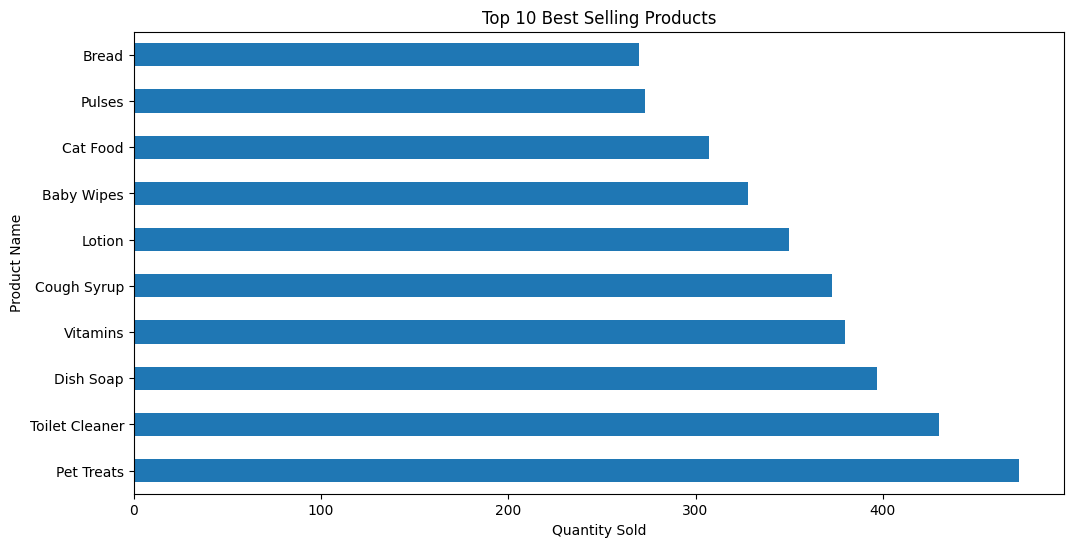

In [46]:
plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Best Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")

plt.show()

## Analysis 5: Top 10 Best-Selling Products

### Business Question
Which products are sold the most?

### Observation
The visualization shows the ten products with the highest quantities sold.

### Business Insight
These products should always be adequately stocked. Blinkit can also use them for promotions, cross-selling, and demand forecasting.

In [47]:
category_revenue = (
    master_data.groupby("category")["order_total"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Dairy & Breakfast        1244368.69
Household Care           1136440.47
Pet Care                 1125103.80
Fruits & Vegetables      1085102.76
Pharmacy                 1055811.97
Snacks & Munchies        1043581.94
Grocery & Staples        1005494.87
Personal Care            1003163.40
Cold Drinks & Juices      828002.23
Instant & Frozen Food     741183.31
Baby Care                 741055.06
Name: order_total, dtype: float64

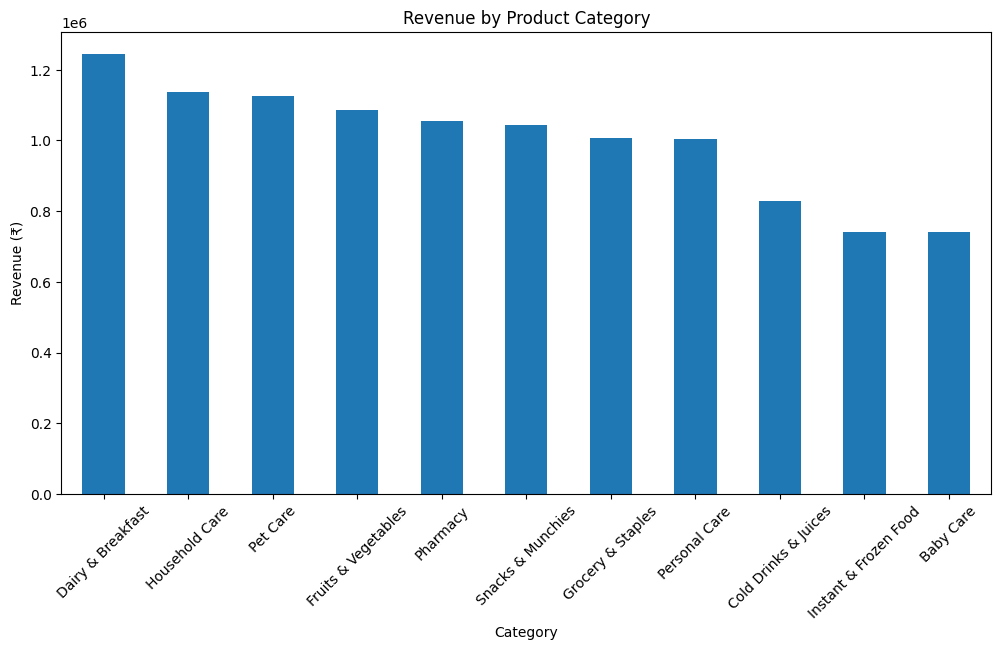

In [48]:
plt.figure(figsize=(12,6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

## Analysis 6: Revenue by Product Category

### Business Question
Which product categories generate the highest revenue?

### Observation
The chart compares the total revenue generated by each product category.

### Business Insight
High-revenue categories should receive greater inventory allocation, promotional campaigns, and marketing investment to maximize profitability.

In [49]:
total_orders = master_data["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5000


In [50]:
total_customers = master_data["customer_id"].nunique()
print("Total Customers:", total_customers)

Total Customers: 2172


In [51]:
total_products = master_data["product_id"].nunique()
print("Total Products:", total_products)

Total Products: 268


In [52]:
average_order_value = master_data["order_total"].mean()
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 2201.86


In [53]:
top_customers = (
    master_data.groupby("customer_id")["order_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

customer_id
22210238    21686.80
77869660    19052.94
8791577     19028.36
26285589    18912.97
91196901    18856.11
17805991    18409.90
17597449    17857.34
11478478    17719.29
25128143    17638.83
67092149    17572.43
Name: order_total, dtype: float64

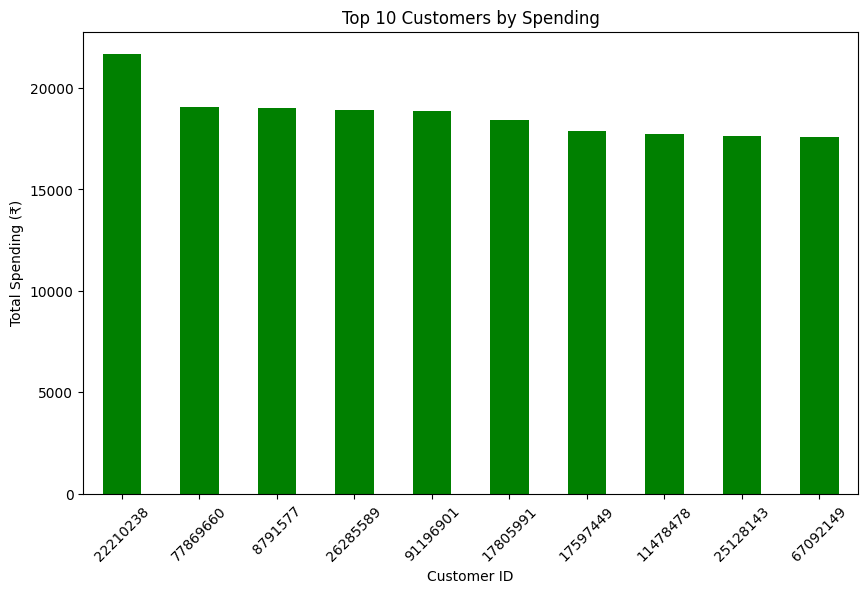

In [54]:
plt.figure(figsize=(10,6))

top_customers.plot(kind="bar", color="green")

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending (₹)")

plt.xticks(rotation=45)

plt.show()

In [55]:
brand_revenue = (
    master_data.groupby("brand")["order_total"]
    .sum()
    .sort_values(ascending=False)
)

brand_revenue

brand
Mandal-Kar                77830.82
Karnik PLC                75330.75
Kurian-Chhabra            71356.43
Roy-Char                  70374.94
Basu and Sons             68301.33
                            ...   
Dubey-Sarin               21095.61
Andra, Mander and Kari    20498.33
Raj and Sons              19575.04
Prasad LLC                16201.28
Gaba LLC                  10529.79
Name: order_total, Length: 267, dtype: float64

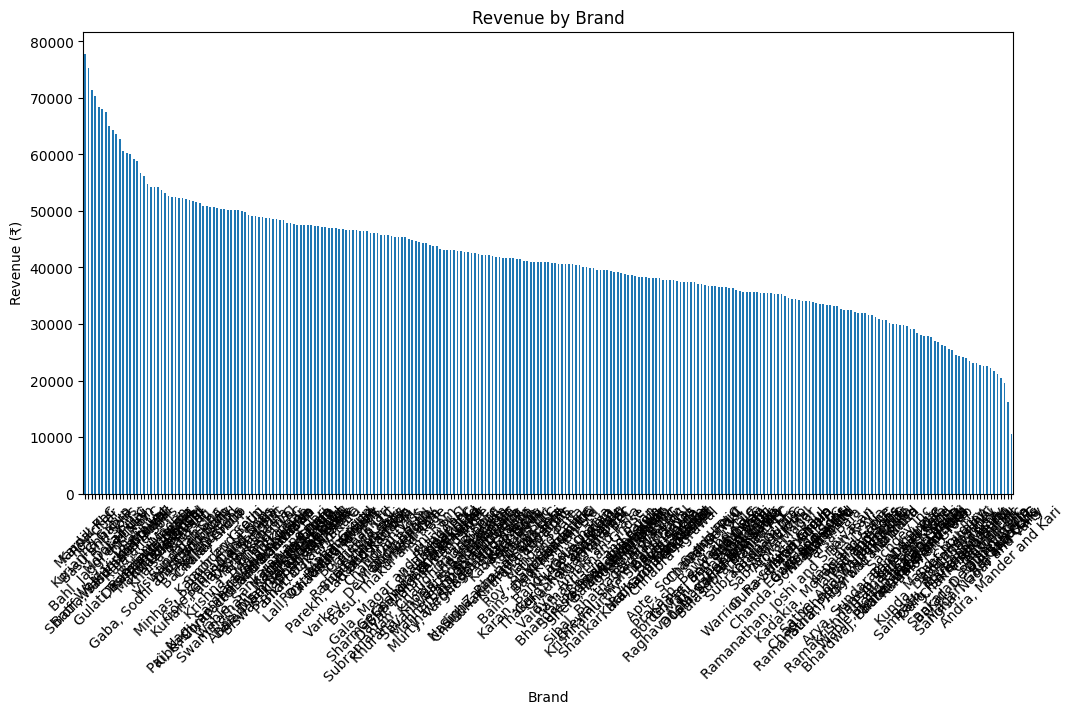

In [56]:
plt.figure(figsize=(12,6))

brand_revenue.plot(kind="bar")

plt.title("Revenue by Brand")
plt.xlabel("Brand")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

In [57]:
avg_price = (
    master_data.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price

category
Pharmacy                 601.520021
Dairy & Breakfast        574.776396
Fruits & Vegetables      566.480488
Pet Care                 535.208583
Baby Care                521.659311
Cold Drinks & Juices     517.329040
Personal Care            438.945947
Snacks & Munchies        417.271884
Instant & Frozen Food    413.003680
Household Care           409.000511
Grocery & Staples        400.935590
Name: price, dtype: float64

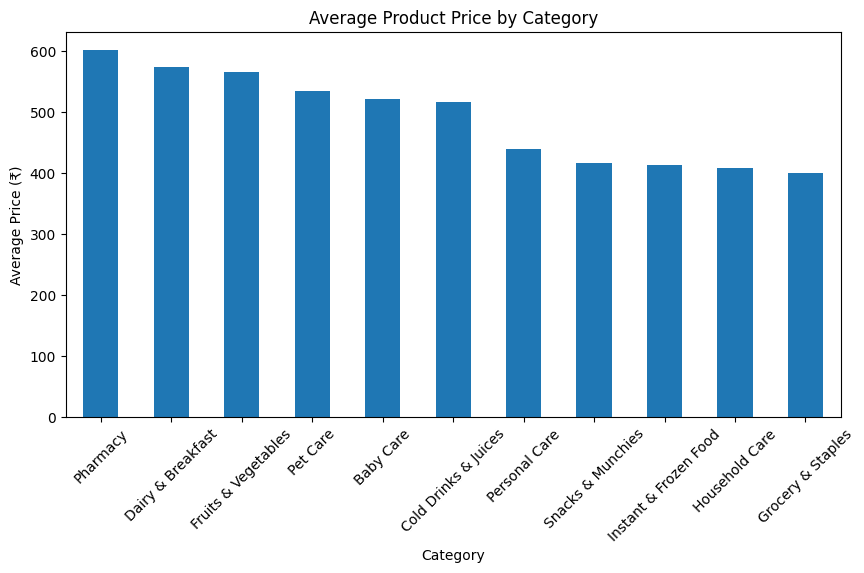

In [58]:
plt.figure(figsize=(10,5))

avg_price.plot(kind="bar")

plt.title("Average Product Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")

plt.xticks(rotation=45)

plt.show()

In [59]:
customers = pd.read_csv("../data/archive (1)/blinkit_customers.csv")

In [60]:
customers.head()


,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [61]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   str    
 2   email              2500 non-null   str    
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   str    
 5   area               2500 non-null   str    
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   str    
 8   customer_segment   2500 non-null   str    
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), str(6)
memory usage: 440.7 KB


In [62]:
customers.columns

Index(['customer_id', 'customer_name', 'email', 'phone', 'address', 'area',
       'pincode', 'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value'],
      dtype='str')

In [63]:
master_data = pd.merge(
    master_data,
    customers,
    on="customer_id",
    how="left"
)

In [64]:
master_data.shape

(5000, 32)

In [65]:
segment_revenue = (
    master_data.groupby("customer_segment")["order_total"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

customer_segment
Regular     2890148.66
New         2795854.48
Premium     2731329.71
Inactive    2591975.65
Name: order_total, dtype: float64

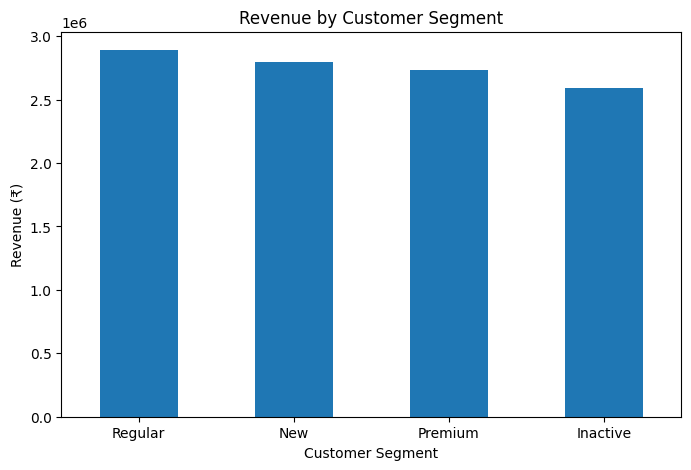

In [66]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=0)

plt.show()

## Analysis 10: Revenue by Customer Segment

### Business Question
Which customer segment contributes the highest revenue?

### Observation
The chart compares total revenue generated by each customer segment.

### Business Insight
The highest revenue-generating customer segment should be prioritized with personalized offers, loyalty rewards, and targeted marketing campaigns.

In [67]:
area_revenue = (
    master_data.groupby("area")["order_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

area_revenue

area
Orai           99590.96
Deoghar        95386.05
Nandyal        83281.10
Gandhinagar    82273.95
Bhopal         78854.32
Ghaziabad      72599.85
Ahmednagar     72233.14
Jabalpur       70135.67
Jalna          69086.31
Ratlam         67426.31
Name: order_total, dtype: float64

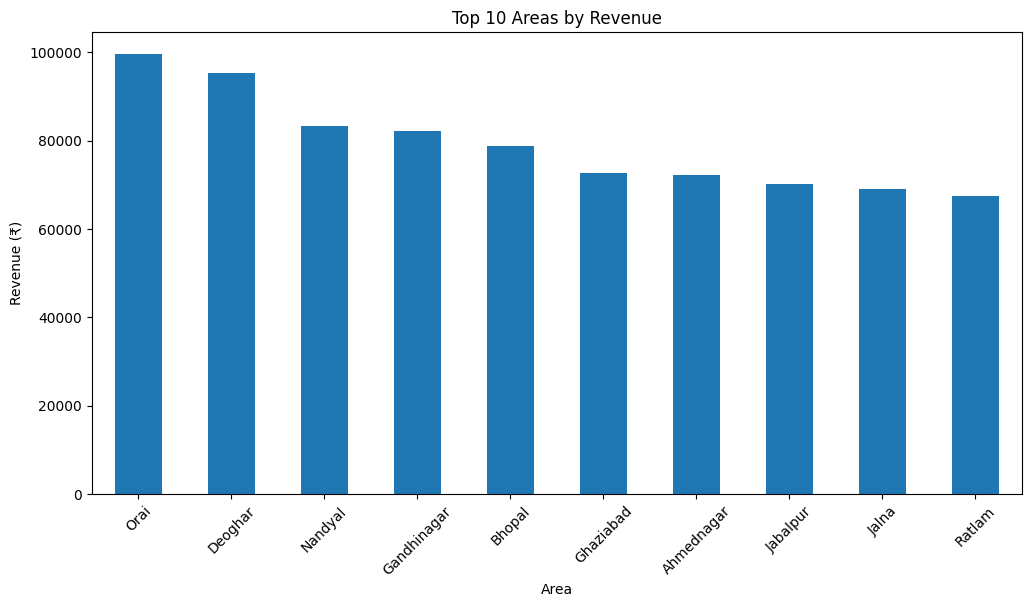

In [68]:
plt.figure(figsize=(12,6))

area_revenue.plot(kind="bar")

plt.title("Top 10 Areas by Revenue")
plt.xlabel("Area")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

In [69]:
delivery = pd.read_csv("../data/archive (1)/blinkit_delivery_performance.csv")

In [70]:
delivery.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [71]:
delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               5000 non-null   int64  
 1   delivery_partner_id    5000 non-null   int64  
 2   promised_time          5000 non-null   str    
 3   actual_time            5000 non-null   str    
 4   delivery_time_minutes  5000 non-null   float64
 5   distance_km            5000 non-null   float64
 6   delivery_status        5000 non-null   str    
 7   reasons_if_delayed     3098 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 570.0 KB


In [72]:
delivery.columns

Index(['order_id', 'delivery_partner_id', 'promised_time', 'actual_time',
       'delivery_time_minutes', 'distance_km', 'delivery_status',
       'reasons_if_delayed'],
      dtype='str')

In [74]:
master_data = pd.merge(
    master_data,
    delivery,
    on="order_id",
    how="left"
)

In [75]:
master_data.shape

(5000, 46)

In [76]:
delivery.columns

Index(['order_id', 'delivery_partner_id', 'promised_time', 'actual_time',
       'delivery_time_minutes', 'distance_km', 'delivery_status',
       'reasons_if_delayed'],
      dtype='str')

In [77]:
average_delivery = delivery["delivery_time_minutes"].mean()
print(f"Average Delivery Time: {average_delivery:.2f} minutes")

Average Delivery Time: 4.44 minutes


In [78]:
delivery_status = delivery["delivery_status"].value_counts()
delivery_status

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

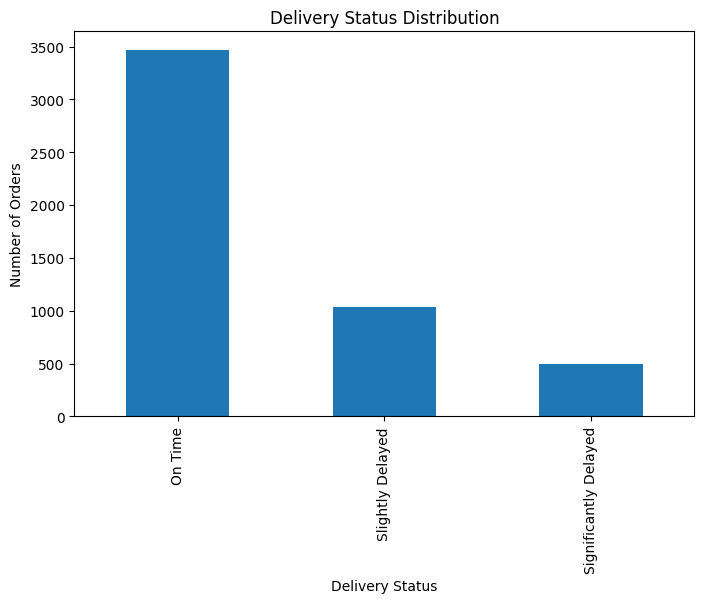

In [79]:
plt.figure(figsize=(8,5))

delivery_status.plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.show()

## Analysis 12: Delivery Status Distribution

### Business Question
How are deliveries distributed across different delivery statuses?

### Business Insight
A higher percentage of delayed deliveries indicates operational bottlenecks. Blinkit can investigate logistics, staffing, or traffic conditions to improve customer satisfaction.

In [80]:
avg_time_status = (
    delivery.groupby("delivery_status")["delivery_time_minutes"]
    .mean()
    .sort_values()
)

avg_time_status

delivery_status
On Time                   0.013833
Slightly Delayed         10.515911
Significantly Delayed    22.843813
Name: delivery_time_minutes, dtype: float64

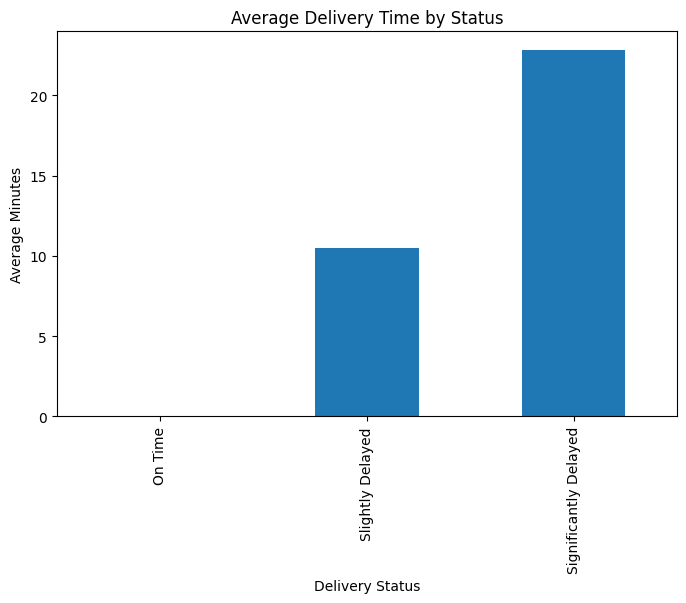

In [81]:
plt.figure(figsize=(8,5))

avg_time_status.plot(kind="bar")

plt.title("Average Delivery Time by Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Minutes")

plt.show()

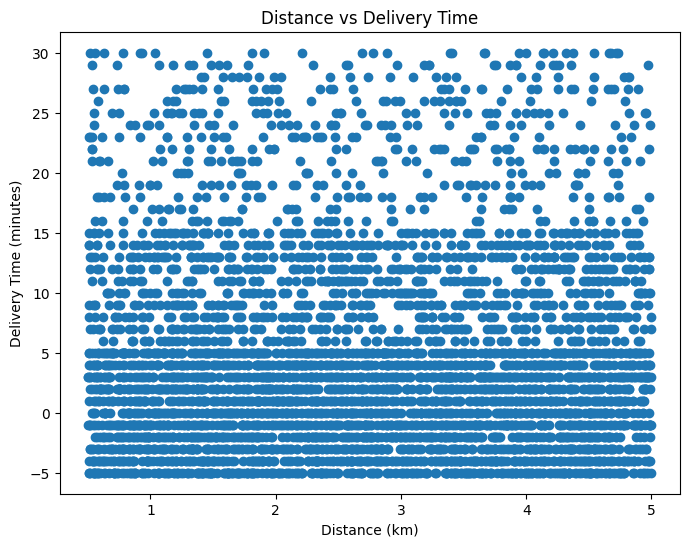

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(
    delivery["distance_km"],
    delivery["delivery_time_minutes"]
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

In [83]:
delay_reasons = (
    delivery["reasons_if_delayed"]
    .value_counts()
)

delay_reasons

reasons_if_delayed
Traffic    3098
Name: count, dtype: int64

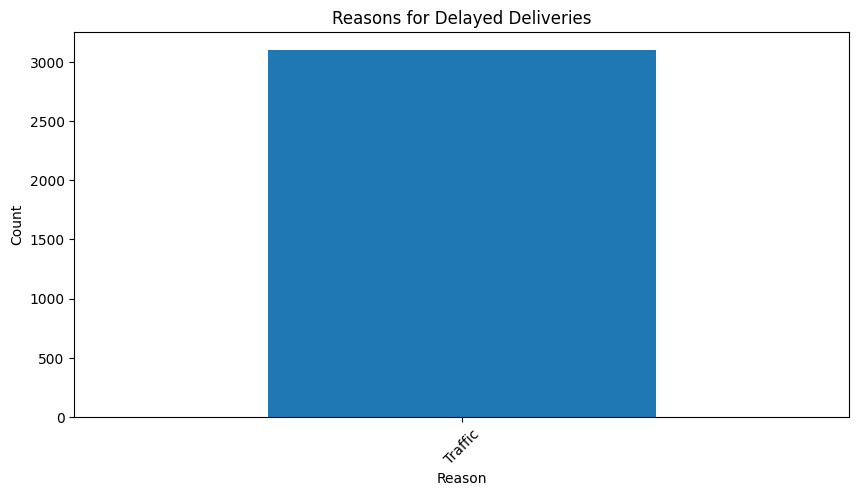

In [84]:
plt.figure(figsize=(10,5))

delay_reasons.plot(kind="bar")

plt.title("Reasons for Delayed Deliveries")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [85]:
feedback = pd.read_csv("../data/archive (1)/blinkit_customer_feedback.csv")

In [86]:
feedback.head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [87]:
feedback.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   feedback_id        5000 non-null   int64
 1   order_id           5000 non-null   int64
 2   customer_id        5000 non-null   int64
 3   rating             5000 non-null   int64
 4   feedback_text      5000 non-null   str  
 5   feedback_category  5000 non-null   str  
 6   sentiment          5000 non-null   str  
 7   feedback_date      5000 non-null   str  
dtypes: int64(4), str(4)
memory usage: 624.4 KB


In [88]:
feedback.columns

Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_text',
       'feedback_category', 'sentiment', 'feedback_date'],
      dtype='str')

## Analysis X: Title

### Business Question
(What are we trying to answer?)

### Code

(Python code)

### Visualization

(Chart)

### Key Insights
• Insight 1
• Insight 2
• Insight 3

### Business Recommendation
(What should Blinkit do?)

In [89]:
average_rating = feedback["rating"].mean()

print(f"Average Customer Rating: {average_rating:.2f}")

Average Customer Rating: 3.34


In [90]:
rating_distribution = feedback["rating"].value_counts().sort_index()

rating_distribution

rating
1     540
2     538
3    1398
4    1708
5     816
Name: count, dtype: int64

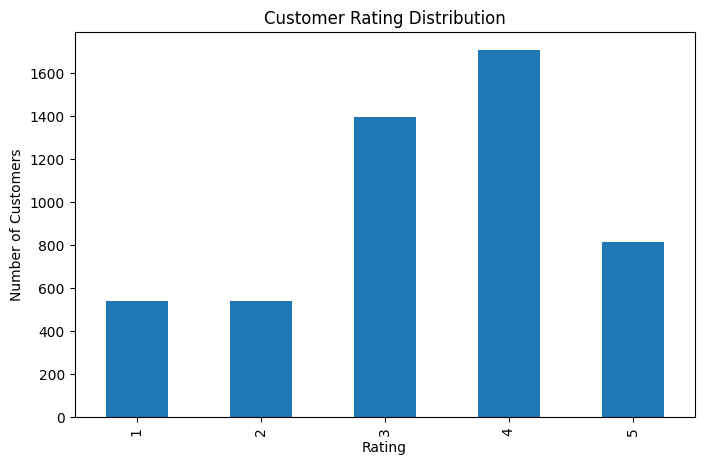

In [91]:
plt.figure(figsize=(8,5))

rating_distribution.plot(kind="bar")

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 17: Customer Rating Distribution

### Business Question
How are customer ratings distributed?

### Business Insight
A higher concentration of 4-star and 5-star ratings indicates strong customer satisfaction. Lower ratings highlight opportunities to improve service quality and customer experience.

In [92]:
sentiment_count = feedback["sentiment"].value_counts()

sentiment_count

sentiment
Neutral     1738
Negative    1642
Positive    1620
Name: count, dtype: int64

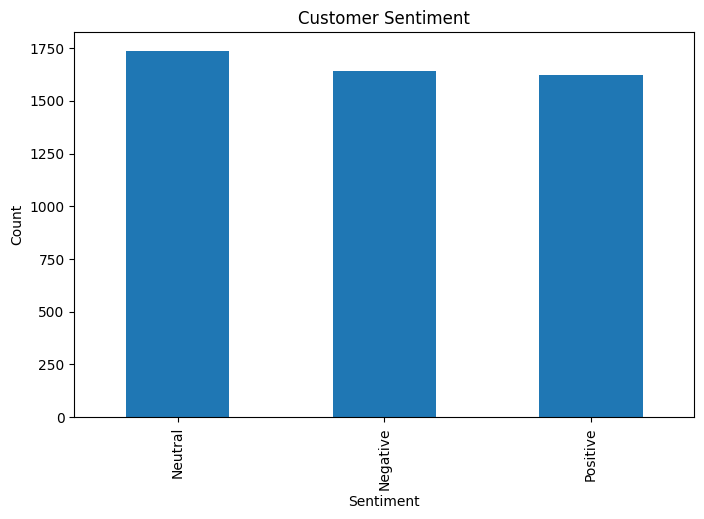

In [93]:
plt.figure(figsize=(8,5))

sentiment_count.plot(kind="bar")

plt.title("Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## Analysis 18: Customer Sentiment

### Business Question
What is the overall customer sentiment?

### Business Insight
Positive sentiment indicates satisfied customers, while negative sentiment highlights areas requiring operational improvements.

In [94]:
feedback_category = feedback["feedback_category"].value_counts()

feedback_category

feedback_category
Delivery            1271
Customer Service    1266
Product Quality     1250
App Experience      1213
Name: count, dtype: int64

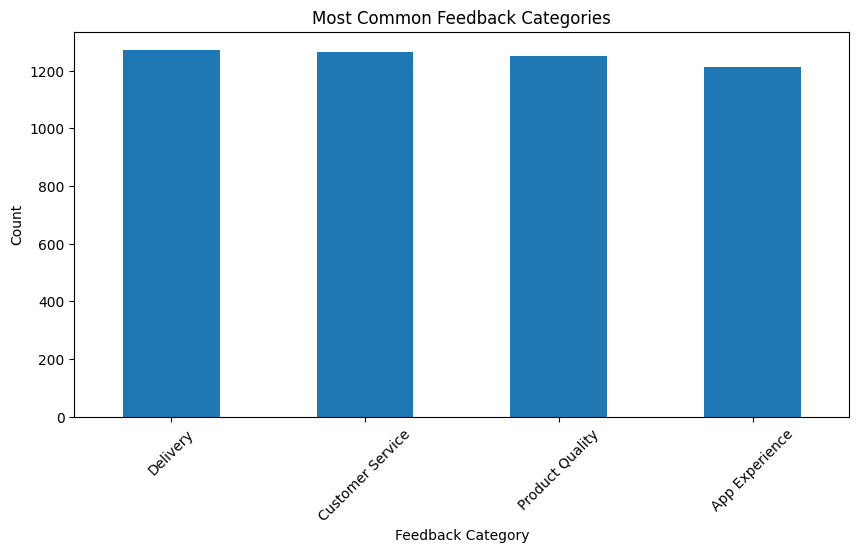

In [95]:
plt.figure(figsize=(10,5))

feedback_category.plot(kind="bar")

plt.title("Most Common Feedback Categories")
plt.xlabel("Feedback Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Analysis 19: Feedback Categories

### Business Question
Which types of feedback are most common?

### Business Insight
Frequently reported issues should be prioritized for operational improvements to enhance customer satisfaction and reduce complaints.

In [96]:
#Inventory Analysis
inventory = pd.read_csv("../data/archive (1)/blinkit_inventory.csv")

In [97]:
inventory.head()

,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2


In [98]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_id      75172 non-null  int64
 1   date            75172 non-null  str  
 2   stock_received  75172 non-null  int64
 3   damaged_stock   75172 non-null  int64
dtypes: int64(3), str(1)
memory usage: 3.0 MB


In [99]:
inventory.columns

Index(['product_id', 'date', 'stock_received', 'damaged_stock'], dtype='str')

In [100]:
inventory_master = pd.merge(
    inventory,
    products,
    on="product_id",
    how="left"
)

inventory_master.head()

,product_id,date,stock_received,damaged_stock,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,17-03-2023,4,2,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,848226,17-03-2023,4,2,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
2,965755,17-03-2023,1,0,Bananas,Fruits & Vegetables,"Doshi, Sarraf and Sama",532.57,710.09,25.0,3,21,91
3,39154,17-03-2023,4,0,Mangoes,Fruits & Vegetables,"Suresh, Bose and Bajwa",946.86,1262.48,25.0,3,21,84
4,34186,17-03-2023,3,2,Mangoes,Fruits & Vegetables,Mandal-Kar,925.65,1234.20,25.0,3,27,74


In [101]:
stock_received = (
    inventory_master.groupby("product_name")["stock_received"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

stock_received

product_name
Pet Treats        8532
Vitamins          6745
Cough Syrup       6477
Toilet Cleaner    5164
Pulses            5079
Lotion            5024
Cat Food          4960
Baby Wipes        4797
Pain Reliever     4096
Dog Food          4029
Name: stock_received, dtype: int64

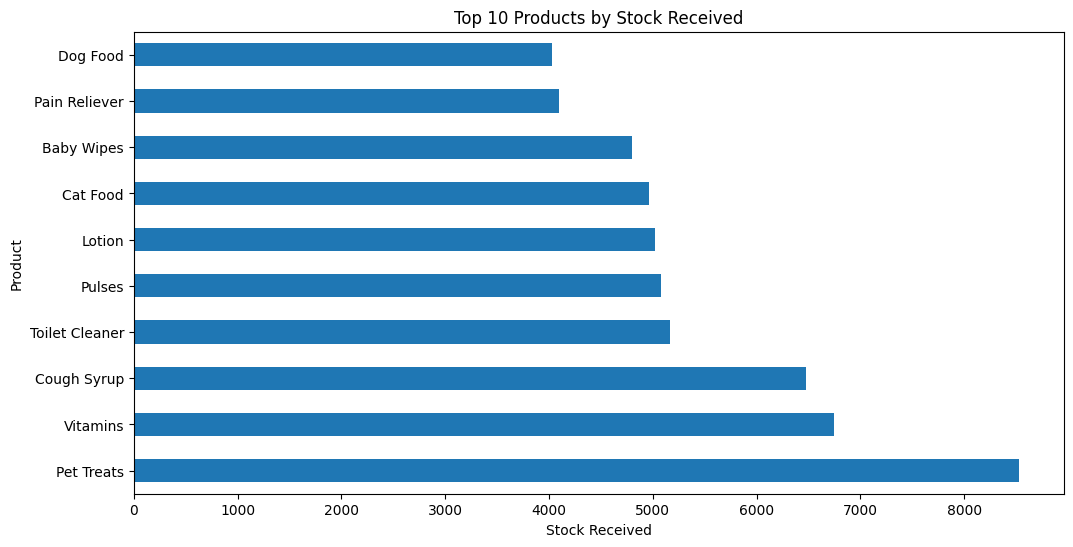

In [102]:
plt.figure(figsize=(12,6))

stock_received.plot(kind="barh")

plt.title("Top 10 Products by Stock Received")
plt.xlabel("Stock Received")
plt.ylabel("Product")

plt.show()

## Analysis 20: Top Products by Stock Received

### Business Question
Which products receive the highest inventory?

### Business Insight
Products receiving large inventory volumes are likely to have higher demand. Monitoring these products helps ensure continuous availability while avoiding stock shortages.

In [103]:
damaged_stock = (
    inventory_master.groupby("product_name")["damaged_stock"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

damaged_stock

product_name
Pet Treats        3494
Toilet Cleaner    3030
Dish Soap         3022
Lotion            3016
Vitamins          2940
Cough Syrup       2620
Baby Wipes        2484
Pulses            2482
Detergent         2158
Bread             2122
Name: damaged_stock, dtype: int64

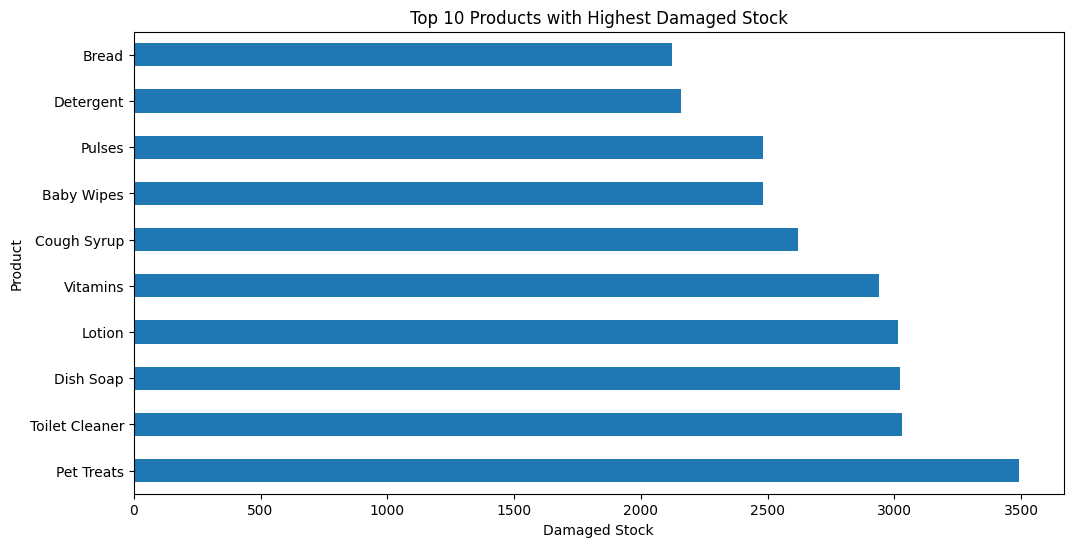

In [104]:
plt.figure(figsize=(12,6))

damaged_stock.plot(kind="barh")

plt.title("Top 10 Products with Highest Damaged Stock")
plt.xlabel("Damaged Stock")
plt.ylabel("Product")

plt.show()

## Analysis 21: Damaged Stock Analysis

### Business Question
Which products have the highest damaged stock?

### Business Insight
Products with high damaged stock increase operational costs. Blinkit should investigate storage, transportation, and supplier quality for these products.

In [105]:
print("Total Stock Received:", inventory["stock_received"].sum())

print("Total Damaged Stock:", inventory["damaged_stock"].sum())

Total Stock Received: 147526
Total Damaged Stock: 80268


In [106]:
damage_percentage = (
    inventory["damaged_stock"].sum()
    /
    inventory["stock_received"].sum()
) * 100

print(f"Damage Percentage: {damage_percentage:.2f}%")

Damage Percentage: 54.41%


In [108]:
#Marketing Analysis
marketing = pd.read_csv("../data/archive (1)/blinkit_marketing_performance.csv")


In [109]:
marketing.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [110]:
marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        5400 non-null   int64  
 1   campaign_name      5400 non-null   str    
 2   date               5400 non-null   str    
 3   target_audience    5400 non-null   str    
 4   channel            5400 non-null   str    
 5   impressions        5400 non-null   int64  
 6   clicks             5400 non-null   int64  
 7   conversions        5400 non-null   int64  
 8   spend              5400 non-null   float64
 9   revenue_generated  5400 non-null   float64
 10  roas               5400 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 665.4 KB


In [111]:
marketing.columns

Index(['campaign_id', 'campaign_name', 'date', 'target_audience', 'channel',
       'impressions', 'clicks', 'conversions', 'spend', 'revenue_generated',
       'roas'],
      dtype='str')

In [112]:
campaign_revenue = (
    marketing.groupby("campaign_name")["revenue_generated"]
    .sum()
    .sort_values(ascending=False)
)

campaign_revenue

campaign_name
Referral Program         3691382.60
New User Discount        3603860.17
Email Campaign           3601785.22
Category Promotion       3582455.37
Weekend Special          3571451.83
Flash Sale               3556087.02
App Push Notification    3554370.00
Membership Drive         3524951.25
Festival Offer           3507063.91
Name: revenue_generated, dtype: float64

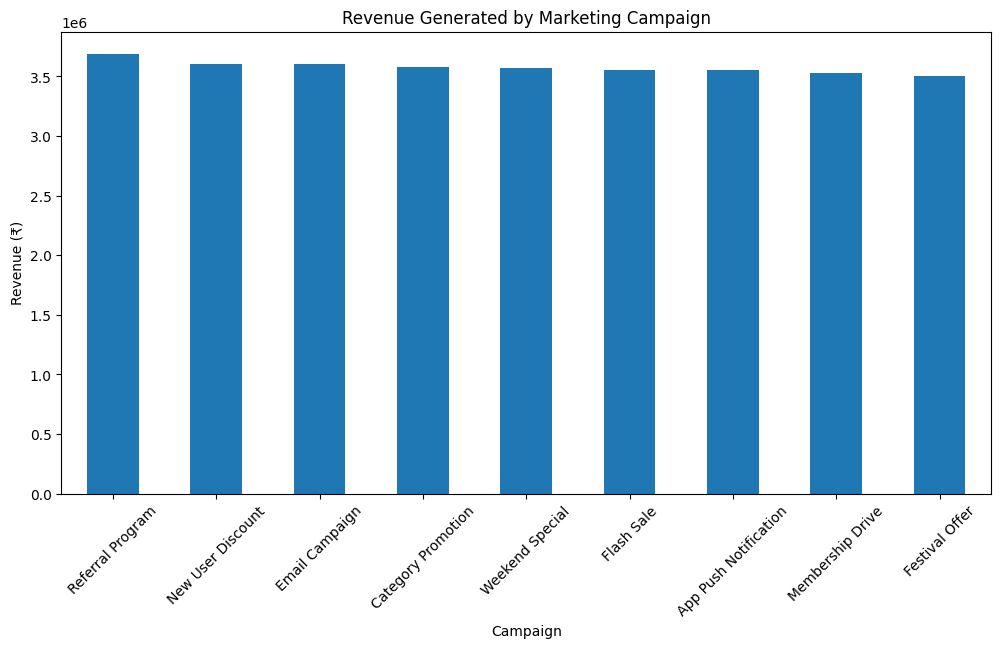

In [113]:
plt.figure(figsize=(12,6))

campaign_revenue.plot(kind="bar")

plt.title("Revenue Generated by Marketing Campaign")
plt.xlabel("Campaign")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

In [114]:
channel_spend = (
    marketing.groupby("channel")["spend"]
    .sum()
    .sort_values(ascending=False)
)

channel_spend

channel
App             4213378.75
Social Media    4110363.91
SMS             3998607.54
Email           3997488.04
Name: spend, dtype: float64

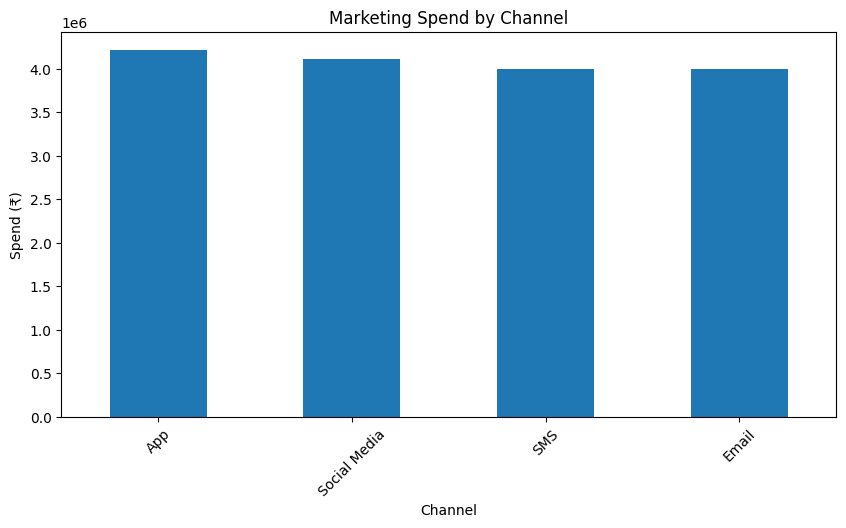

In [115]:
plt.figure(figsize=(10,5))

channel_spend.plot(kind="bar")

plt.title("Marketing Spend by Channel")
plt.xlabel("Channel")
plt.ylabel("Spend (₹)")

plt.xticks(rotation=45)

plt.show()

In [116]:
campaign_roas = (
    marketing.groupby("campaign_name")["roas"]
    .mean()
    .sort_values(ascending=False)
)

campaign_roas

campaign_name
Email Campaign           2.777067
Festival Offer           2.765917
App Push Notification    2.760817
New User Discount        2.754950
Referral Program         2.743450
Weekend Special          2.743333
Membership Drive         2.719833
Flash Sale               2.711067
Category Promotion       2.689967
Name: roas, dtype: float64

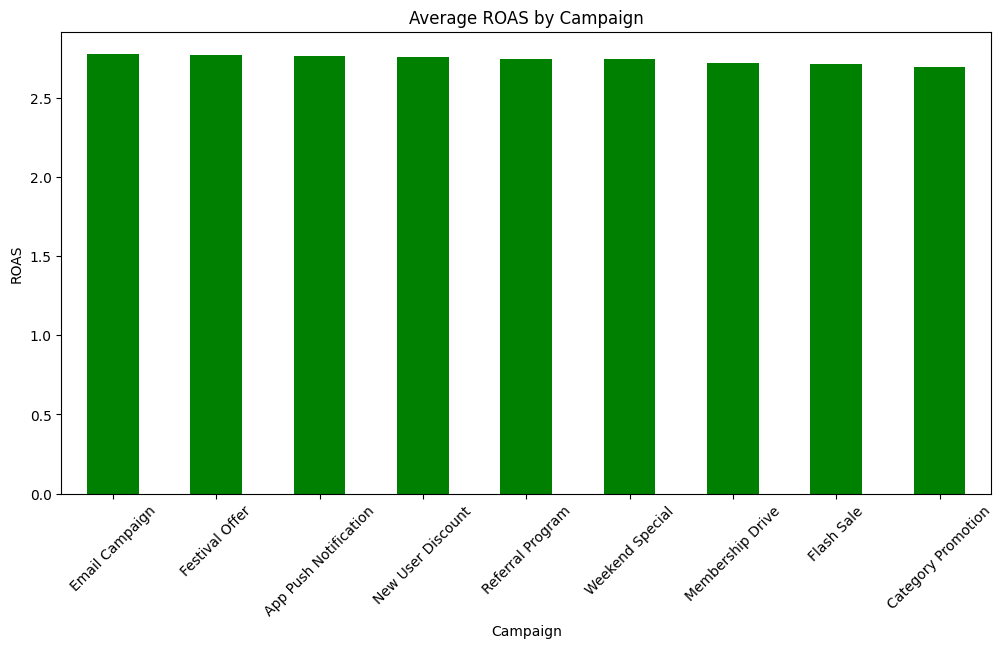

In [117]:
plt.figure(figsize=(12,6))

campaign_roas.plot(kind="bar", color="green")

plt.title("Average ROAS by Campaign")
plt.xlabel("Campaign")
plt.ylabel("ROAS")

plt.xticks(rotation=45)

plt.show()

In [118]:
marketing["conversion_rate"] = (
    marketing["conversions"] /
    marketing["clicks"]
) * 100

In [119]:
conversion_rate = (
    marketing.groupby("channel")["conversion_rate"]
    .mean()
    .sort_values(ascending=False)
)

conversion_rate

channel
Social Media    14.613404
App             14.489363
SMS             13.885729
Email           13.842393
Name: conversion_rate, dtype: float64

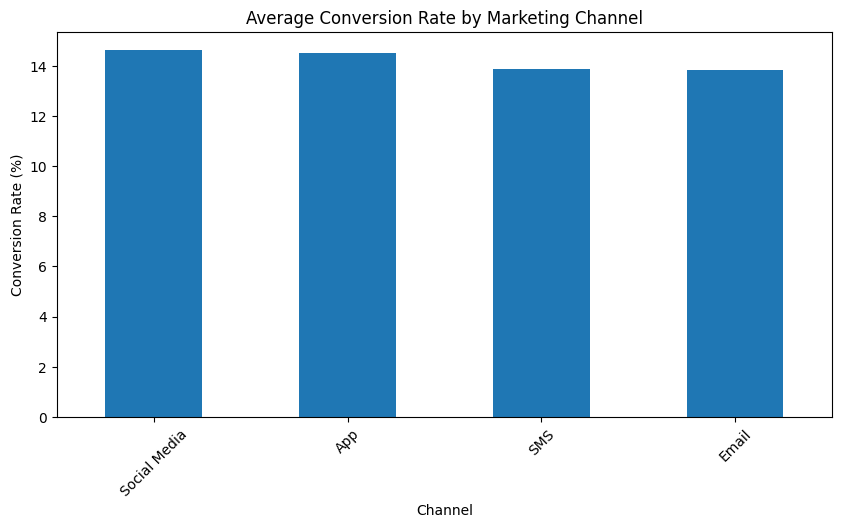

In [120]:
plt.figure(figsize=(10,5))

conversion_rate.plot(kind="bar")

plt.title("Average Conversion Rate by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.show()